# **Notebook 1b Data exploration**

## 1. Importing the packages

In [1]:
# Loading the packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

## 2. Loading the dataset

In [2]:
dataset = "dataset_cleaned.tsv"
df = pd.read_csv(dataset, sep="\t", on_bad_lines="warn", low_memory=False)

In [3]:
dataset = "dataset2.tsv"
data = pd.read_csv(dataset, sep="\t", on_bad_lines="warn", low_memory=False)

/var/folders/c1/_vnm4tbd57174gws_3j9hz7h0000gn/T/ipykernel_32437/3025923279.py:2: ParserWarning: Skipping line 53: expected 55 fields, saw 56
Skipping line 111: expected 55 fields, saw 60
Skipping line 243: expected 55 fields, saw 58
Skipping line 297: expected 55 fields, saw 65
Skipping line 301: expected 55 fields, saw 60
Skipping line 420: expected 55 fields, saw 58
Skipping line 443: expected 55 fields, saw 59
Skipping line 536: expected 55 fields, saw 63
Skipping line 582: expected 55 fields, saw 62
Skipping line 631: expected 55 fields, saw 59
Skipping line 672: expected 55 fields, saw 62
Skipping line 797: expected 55 fields, saw 56
Skipping line 924: expected 55 fields, saw 57
Skipping line 948: expected 55 fields, saw 57
Skipping line 955: expected 55 fields, saw 57
Skipping line 958: expected 55 fields, saw 59
Skipping line 1069: expected 55 fields, saw 60
Skipping line 1169: expected 55 fields, saw 57
Skipping line 1170: expected 55 fields, saw 58
Skipping line 1171: expecte

In [4]:
print(data.columns.tolist())

['isbn', 'baf', 'annotated_text', 'first_version', 'second_version', 'FNF', 'VJ', 'agecat', 'title', 'subtitle', 'publishing_date', 'publishing_date_original', 'title_original', 'language_original', 'series_name', 'series_part', 'series_index', 'edition', 'publisher', 'pages', 'num_pages', 'language_original_name', 'language_original_adjective_neuter', 'language_original_adjective_mf', 'is_translation', 'is_title_original_different', 'translator', 'author_name', 'author_surname', 'pseudonym', 'birthdate', 'birth_year', 'deathdate', 'death_year', 'death_age', 'publishing_age', 'birthplace', 'deathplace', 'nationalities', 'nationality_adjective_mf', 'nationality_adjective_neuters', 'nationality_country_names', 'awards', 'bibliography', 'bibliography_place', 'countries_published', 'known_works', 'product_form', 'debut', 'debut_year', 'author_status', 'title_status', 'professions', 'genres', 'blurb']


In [5]:
# Optie 1: dropna() - filtert NA's eruit
df['product_form'].dropna().head(1000)

# Optie 2: met notna() als filter
df[df['product_form'].notna()]['product_form'].head(20)

0     Paperback
2     Paperback
3     Paperback
4     Paperback
5     Paperback
6     Paperback
7     Paperback
8     Paperback
9     Paperback
10    Paperback
11    Paperback
12    Paperback
14    Paperback
15    Paperback
16    Paperback
17    Paperback
19    Paperback
20    Paperback
21    Paperback
23    Paperback
Name: product_form, dtype: object

In [6]:
# Exacte match (hoofdlettergevoelig)
df[df['author_name'] == 'Arne van der Ree']

# Bevat de naam (case-insensitive, veiliger)
df[df['author_name'].str.contains('Arne van der Ree', case=False, na=False)]

# Alleen op achternaam zoeken
df[df['author_name'].str.contains('van der Ree', case=False, na=False)]

,isbn,baf,final_edit,automatic_output,intermediate_edit,FNF,VJ,agecat,title,subtitle,...,countries_published,known_works,product_form,debut,debut_year,author_status,title_status,professions,genres,blurb


## 3. Showing insightfull plots

In [7]:
# Counting amount of words in selected text columns
TEXT_COLS = ["automatic_output", "final_edit", "blurb"]
for col in TEXT_COLS:
    df[f"{col}_wc"] = df[col].where(df[col].notna()).astype("string").str.split().str.len()

# Setting unexpected values to NaN. Original columns are preserved.
fnf_clean = df["FNF"].where(df["FNF"].isin(["F", "NF"]), np.nan)
df["FNF_clean"] = fnf_clean
df["VJ_clean"]  = df["VJ"].where(df["VJ"].isin(["V", "J"]), np.nan)

# Define colors
# Define colour palette for all plots
PURPLE = "#6c5ce7"
TEAL   = "#1abc9c"
CORAL  = "#ff7675"
GRAY   = "#95a5a6"

### 3.1 Word count distributions across text fields


/var/folders/c1/_vnm4tbd57174gws_3j9hz7h0000gn/T/ipykernel_32437/951244432.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


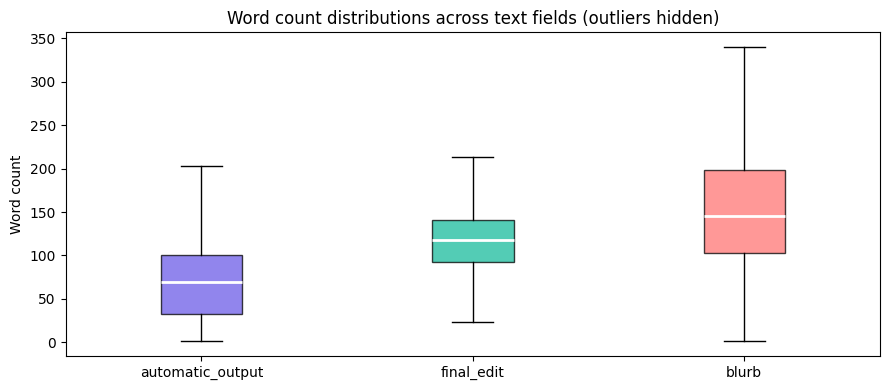

In [8]:
# Collecting word-count values per text column, dropping NaNs
data_for_box = [df[f"{c}_wc"].dropna().values for c in TEXT_COLS]

# Creating boxplot; outliers hidden for readability
fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot(
    data_for_box,
    labels=TEXT_COLS,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="white", linewidth=2),
)

# Applying custom colours per box
for patch, color in zip(bp["boxes"], [PURPLE, TEAL, CORAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Labels and layout
ax.set_ylabel("Word count")
ax.set_title("Word count distributions across text fields (outliers hidden)")
fig.tight_layout()

### 3.2 Blurb word count histogram

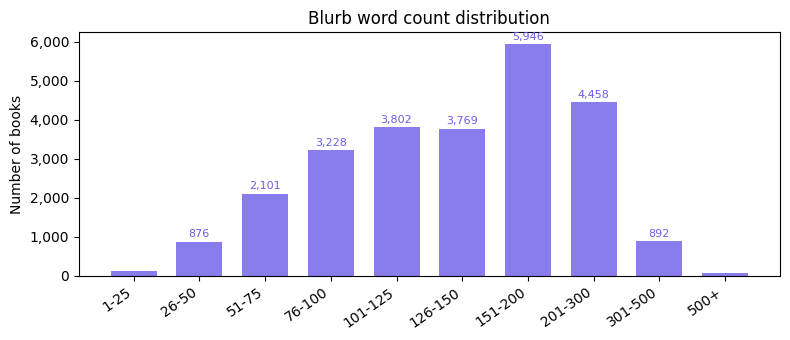

In [9]:
# Bin counts and labels for blurb word count distribution
counts     = [130, 876, 2101, 3228, 3802, 3769, 5946, 4458, 892, 70]
bin_labels = ["1-25", "26-50", "51-75", "76-100", "101-125",
              "126-150", "151-200", "201-300", "301-500", "500+"]

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(range(len(counts)), counts, color=PURPLE, alpha=0.8, width=0.7)

# X-axis: rotated bin labels for readability
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(bin_labels, rotation=35, ha="right")

# Y-axis: thousands separator for readability
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Annotate bars above a threshold to avoid clutter on small bars
for bar, cnt in zip(bars, counts):
    if cnt > 300:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
                f"{cnt:,}", ha="center", va="bottom", fontsize=8, color=PURPLE)

# Labels and layout
ax.set_ylabel("Number of books")
ax.set_title("Blurb word count distribution")
fig.tight_layout()

### 3.3 Corpus balance: Fiction/NF and Adult/Youth


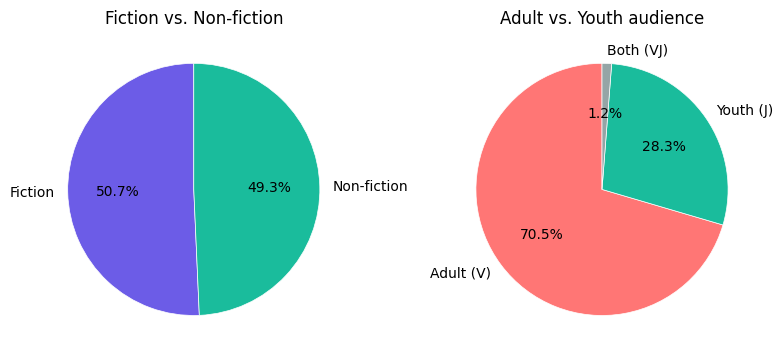

In [10]:
# Counting categories
fnf_counts = fnf_clean.value_counts()
vj_counts  = df["VJ"].value_counts()

# Helper to draw a styled pie chart
def styled_pie(ax, values, labels, colors, title):
    ax.pie(
        values,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(linewidth=0.5, edgecolor="white"),
    )
    ax.set_title(title)

# Defining two side-by-side pie charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
styled_pie(
    ax1,
    [fnf_counts.get("F", 0), fnf_counts.get("NF", 0)],
    ["Fiction", "Non-fiction"],
    [PURPLE, TEAL],
    "Fiction vs. Non-fiction",
)
styled_pie(
    ax2,
    [vj_counts.get("V", 0), vj_counts.get("J", 0), vj_counts.get("VJ", 0)],
    ["Adult (V)", "Youth (J)", "Both (VJ)"],
    [CORAL, TEAL, GRAY],
    "Adult vs. Youth audience",
)
fig.tight_layout()

### 3.4 The top 12 genres

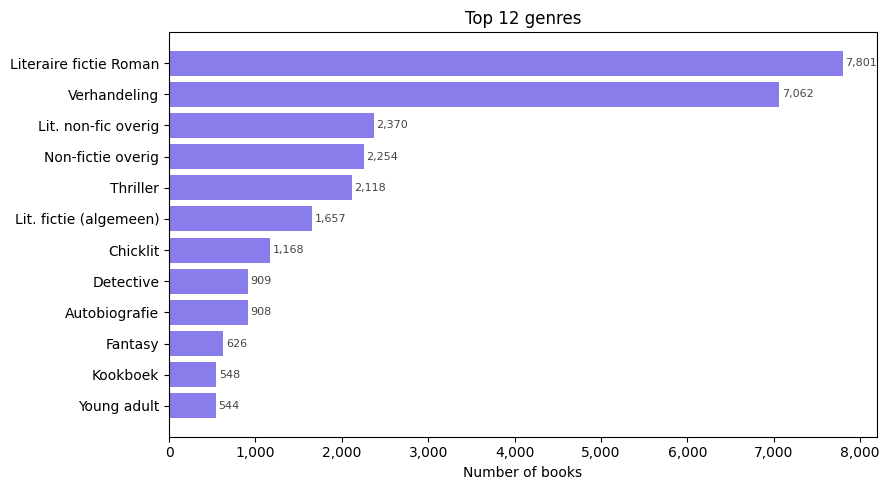

In [11]:
# Explode pipe-separated genres and count top 12
genre_series = df["genres"].dropna().str.split("|").explode().str.strip()
top_genres   = genre_series.value_counts().head(12)

# Shortening unwieldy genre labels for readability
short_labels = top_genres.index.str.replace(
    "Literaire fictie Roman (Roman / verhaal / fictie algemeen)",
    "Lit. fictie (algemeen)",
    regex=False,)

# Horizontal bar chart, descending by count
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(top_genres)), top_genres.values, color=PURPLE, alpha=0.8)
ax.set_yticks(range(len(top_genres)), labels=short_labels)
ax.invert_yaxis()

# x-axis: thousands separator
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Annotating bars with counts
for bar, cnt in zip(bars, top_genres.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", fontsize=8, color="#444")

ax.set_xlabel("Number of books")
ax.set_title("Top 12 genres")
fig.tight_layout()

In [12]:
total_unique_genres = genre_series.nunique()
print(f"Total number of different genres: {total_unique_genres}")

Total number of different genres: 37


### 3.5 Median (and average) word count by audience and type


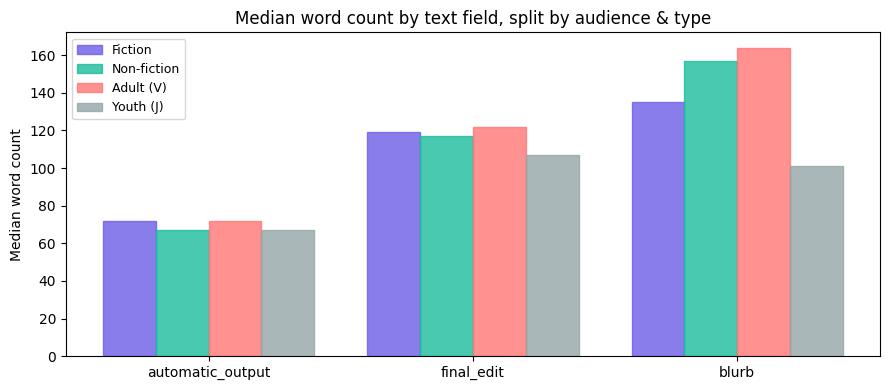

In [13]:
# Computing the median word count per text field for each subgroup
fiction_md = [df[df.FNF_clean == "F"][f"{c}_wc"].median()  for c in TEXT_COLS]
nonfic_md  = [df[df.FNF_clean == "NF"][f"{c}_wc"].median() for c in TEXT_COLS]
adult_md   = [df[df.VJ_clean  == "V"][f"{c}_wc"].median()  for c in TEXT_COLS]
youth_md   = [df[df.VJ_clean  == "J"][f"{c}_wc"].median()  for c in TEXT_COLS]

# Bar positions: 4 groups offset around each x-tick
x     = np.arange(len(TEXT_COLS))
width = 0.2

# Grouped bar chart, one bar per subgroup per text field
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 1.5*width, fiction_md, width, label="Fiction",     color=PURPLE, alpha=0.8, edgecolor=PURPLE)
ax.bar(x - 0.5*width, nonfic_md,  width, label="Non-fiction", color=TEAL,   alpha=0.8, edgecolor=TEAL)
ax.bar(x + 0.5*width, adult_md,   width, label="Adult (V)",   color=CORAL,  alpha=0.8, edgecolor=CORAL)
ax.bar(x + 1.5*width, youth_md,   width, label="Youth (J)",   color=GRAY,   alpha=0.8, edgecolor=GRAY)

# Labels, legend, layout
ax.set_xticks(x)
ax.set_xticklabels(TEXT_COLS)
ax.set_ylabel("Median word count")
ax.set_title("Median word count by text field, split by audience & type", fontweight="normal")
ax.legend(fontsize=9)
fig.tight_layout()

### 3.6 Top 10 source languages of translated books


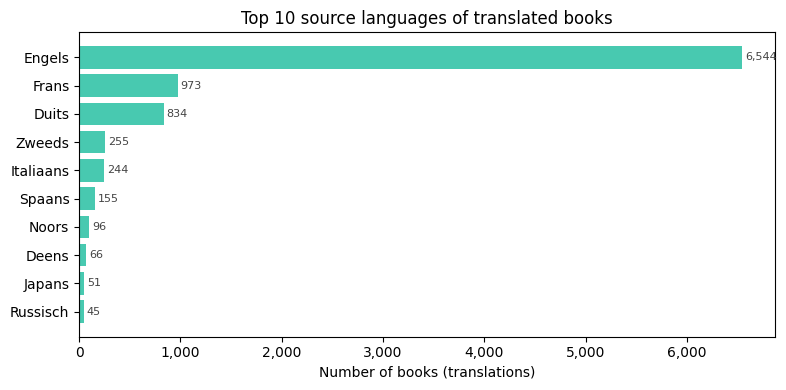

In [14]:
# Explode pipe-separated language strings and count top 10
lang_counts = (
    df["language_original_name"]
    .dropna()
    .str.split("|").explode().str.strip()
    .value_counts()
    .head(10))

# Horizontal bar chart, descending by count
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(lang_counts)), lang_counts.values, color=TEAL, alpha=0.8)
ax.set_yticks(range(len(lang_counts)), labels=lang_counts.index)
ax.invert_yaxis()

# X-axis: thousands separator
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Annotating each bar with its count
for i, cnt in enumerate(lang_counts.values):
    ax.text(cnt + 30, i, f"{cnt:,}", va="center", fontsize=8, color="#444")

# Labels and layout
ax.set_xlabel("Number of books (translations)")
ax.set_title("Top 10 source languages of translated books")
fig.tight_layout()

### 3.7 Duplicate signals


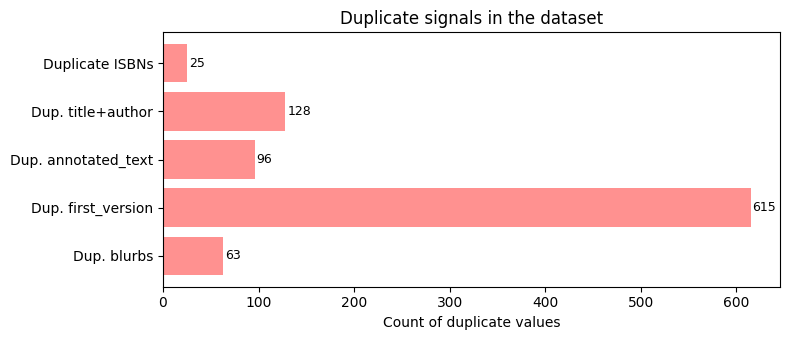

In [15]:
# Counting duplicates across different signal columns
dup_labels = ["Duplicate ISBNs", "Dup. title+author", "Dup. annotated_text",
              "Dup. first_version", "Dup. blurbs"]
dup_counts = [
    df["isbn"].dropna().duplicated().sum(),
    df.dropna(subset=["title", "author_surname"]).duplicated(subset=["title", "author_surname"]).sum(),
    df["final_edit"].duplicated().sum(),
    df["automatic_output"].dropna().duplicated().sum(),
    df["blurb"].dropna().duplicated().sum(),
]

# Horizontal bar chart of duplicate counts
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(range(len(dup_labels)), dup_counts, color=CORAL, alpha=0.8)
ax.set_yticks(range(len(dup_labels)), labels=dup_labels)
ax.invert_yaxis()

# Annotating each bar with its count
for bar, cnt in zip(bars, dup_counts):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(cnt), va="center", fontsize=9)

# Labels and layout
ax.set_xlabel("Count of duplicate values")
ax.set_title("Duplicate signals in the dataset")
fig.tight_layout()